In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import plotly.graph_objects as go
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, mean_absolute_percentage_error
from sklearn.pipeline import make_pipeline
from ipywidgets import interact, IntSlider
%config InlineBackend.figure_format = 'retina'

In [2]:
data_full = pd.read_csv('../datasets/Advertising.csv', index_col = 0)

In [3]:
data_full

,TV,Radio,Newspaper,Sales
1,230.1,37.8,69.2,22.1
2,44.5,39.3,45.1,10.4
3,17.2,45.9,69.3,9.3
4,151.5,41.3,58.5,18.5
5,180.8,10.8,58.4,12.9
...,...,...,...,...
196,38.2,3.7,13.8,7.6
197,94.2,4.9,8.1,9.7
198,177.0,9.3,6.4,12.8
199,283.6,42.0,66.2,25.5


In [4]:
data = data_full.drop('Newspaper', axis = 1)

In [5]:
data

,TV,Radio,Sales
1,230.1,37.8,22.1
2,44.5,39.3,10.4
3,17.2,45.9,9.3
4,151.5,41.3,18.5
5,180.8,10.8,12.9
...,...,...,...
196,38.2,3.7,7.6
197,94.2,4.9,9.7
198,177.0,9.3,12.8
199,283.6,42.0,25.5


In [6]:
X = data[['TV', 'Radio']]

In [7]:
y = data['Sales']

In [8]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 0)

In [9]:
polynomial = PolynomialFeatures(degree = 3)

In [10]:
x_train_polynomial = polynomial.fit_transform(np.array(X_train))

In [11]:
x_train_polynomial

array([[1.00000000e+00, 3.69000000e+01, 3.86000000e+01, ...,
        5.25581460e+04, 5.49795240e+04, 5.75124560e+04],
       [1.00000000e+00, 3.15000000e+01, 2.46000000e+01, ...,
        2.44093500e+04, 1.90625400e+04, 1.48869360e+04],
       [1.00000000e+00, 1.42900000e+02, 2.93000000e+01, ...,
        5.98318013e+05, 1.22678221e+05, 2.51537570e+04],
       ...,
       [1.00000000e+00, 7.64000000e+01, 8.00000000e-01, ...,
        4.66956800e+03, 4.88960000e+01, 5.12000000e-01],
       [1.00000000e+00, 2.39900000e+02, 4.15000000e+01, ...,
        2.38840842e+06, 4.13167775e+05, 7.14733750e+04],
       [1.00000000e+00, 1.96000000e+01, 2.01000000e+01, ...,
        7.72161600e+03, 7.91859600e+03, 8.12060100e+03]])

In [12]:
model = LinearRegression()

In [13]:
model.fit(x_train_polynomial, y_train)

LinearRegression()

In [14]:
model.coef_, model.intercept_

(array([ 0.00000000e+00,  8.46645524e-02,  2.78738872e-02, -3.91772267e-04,
         1.06970455e-03,  2.87622803e-04,  6.36447147e-07,  2.44864551e-07,
        -2.80812472e-06,  5.13491873e-06]),
 np.float64(4.2951493803813925))

In [15]:
x_test_polynomial = polynomial.transform(np.array(X_test))

In [16]:
y_pred = model.predict(x_test_polynomial)

In [17]:
y_pred

array([10.68516476,  8.60719356,  9.25535909, 26.02126108, 12.17779363,
        8.44000714,  8.05129518, 13.01028891,  8.46774891, 16.35538567,
       24.44919973, 10.58687964, 10.91286026, 15.54395048, 11.87488319,
       13.07207227, 17.51281052,  6.25451579, 14.89966007, 17.1699452 ,
       26.12492635, 10.56648816, 15.49060585, 13.2914509 ,  7.97301067,
       15.75999187, 12.56690447, 22.16655308, 11.42530538,  7.82441259,
       12.53068447, 22.96794728, 16.01450231, 22.00281505,  6.09828933,
        6.36941109,  9.22042764, 13.01449789, 13.64598279,  6.81245732])

In [18]:
(y_pred - y_test)[:10]

19    -0.614835
171    0.207194
108    0.555359
99     0.621261
178    0.477794
183   -0.259993
6      0.851295
147   -0.189711
13    -0.732251
153   -0.244614
Name: Sales, dtype: float64

In [19]:
MAPE = mean_absolute_percentage_error(y_test, y_pred)
MAE = mean_absolute_error(y_test, y_pred)
RMSE = np.sqrt(mean_squared_error(y_test, y_pred))

In [20]:
print(f"Mean Absolute Persentage Error: {MAPE:.5f}%")
print(f"Mean Absolute Error: {MAE:.5f}")
print(f"Root Mean Squared Error: {RMSE:.5f}")

Mean Absolute Persentage Error: 0.10110%
Mean Absolute Error: 0.42651
Root Mean Squared Error: 0.83208


In [21]:
degrees = range(1, 15)

print(f"{'Degree':>6}   {'MAE':>10}   {'MAPE (%)':>10}   {'RMSE':>10}")

for degree in degrees:
    polynomial_pipe = make_pipeline(PolynomialFeatures(degree))
    x_train_poly = polynomial_pipe.fit_transform(np.array(X_train))
    model_pipe = LinearRegression()
    model_pipe.fit(x_train_poly, y_train)
    x_test_polynomial = polynomial_pipe.transform(np.array(X_test))
    y_pred = model_pipe.predict(x_test_polynomial)

    mae = mean_absolute_error(y_test, y_pred)
    mape = mean_absolute_percentage_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))

    print(f"{degree:6}   {mae:10.4f}   {mape:10.2f}   {rmse:10.4f}")

Degree          MAE     MAPE (%)         RMSE
     1       1.3724         0.25       2.0956
     2       0.5004         0.12       0.9548
     3       0.4265         0.10       0.8321
     4       0.3955         0.09       0.7592
     5       0.3671         0.09       0.7298
     6       0.4245         0.10       0.7728
     7       0.4877         0.10       0.7853
     8       0.6357         0.11       0.9602
     9       1.1364         0.19       2.1803
    10       0.9081         0.09       1.2864
    11       1.3693         0.15       2.2254
    12       1.6578         0.16       2.8690
    13       1.7288         0.27       2.5263
    14       1.9659         0.29       2.8496


In [22]:
def static_surface(X_train, y_train, degree):
    x0 = np.array(X_train['TV'])
    x1 = np.array(X_train['Radio'])
    y = np.array(y_train)
    X = np.c_[x0, x1]

    x0_range = np.linspace(x0.min(), x0.max(), 30)
    x1_range = np.linspace(x1.min(), x1.max(), 30)
    x0_grid, x1_grid = np.meshgrid(x0_range, x1_range)
    X_grid = np.c_[x0_grid.ravel(), x1_grid.ravel()]

    model = make_pipeline(PolynomialFeatures(degree), LinearRegression())
    model.fit(X, y)
    y_pred = model.predict(X_grid).reshape(x0_grid.shape)

    fig = go.Figure()
    
    fig.add_trace(go.Scatter3d(
    x = x0, y = x1, z = y, mode = 'markers', marker = dict(size = 4, color = 'red'), name = 'Data Points'
    ))
    
    fig.add_trace(go.Surface(
    x = x0_grid, y = x1_grid, z = y_pred, opacity = 0.6, colorscale = 'Viridis', name = 'Polynomial Surface'
    ))
    
    fig.update_layout(
    scene = dict(
        xaxis_title = 'TV', yaxis_title = 'Radio', zaxis_title = 'Sales'
    ),
    title = 'Polynomial regression surface',
    width = 1000,
    height = 700
    )
    
    fig.show()


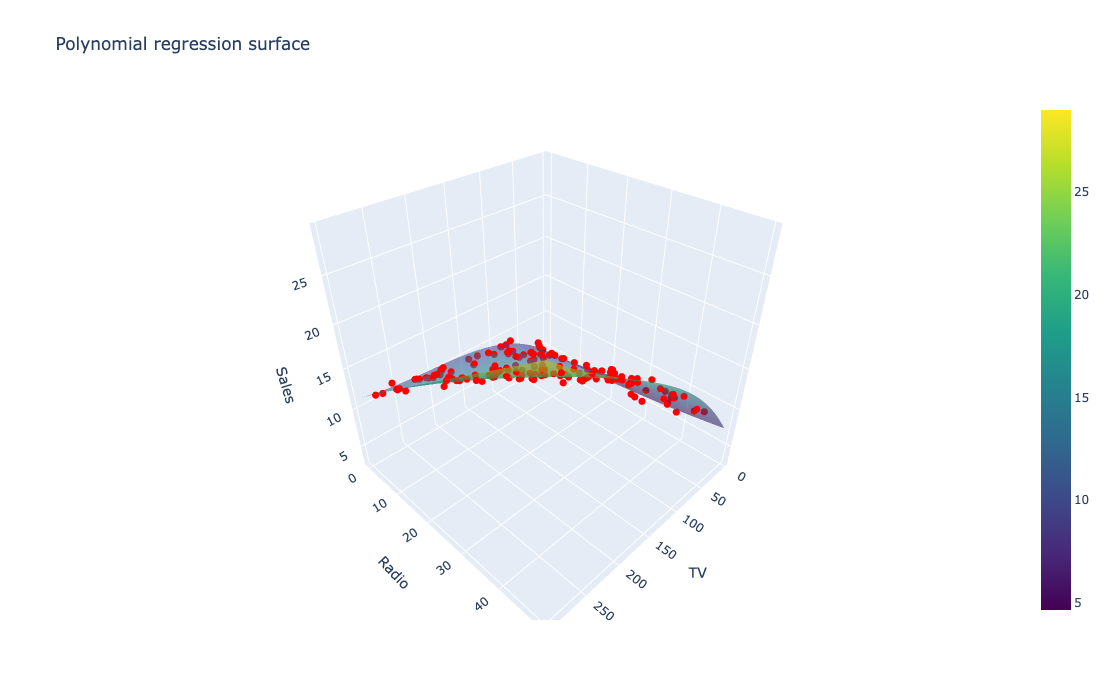

In [23]:
static_surface(X_train, y_train, 3)

In [24]:
x0 = np.array(X_train['TV'])
x1 = np.array(X_train['Radio'])
y = np.array(y_train)
X = np.c_[x0, x1]

x0_range = np.linspace(x0.min(), x0.max(), 30)
x1_range = np.linspace(x1.min(), x1.max(), 30)
x0_grid, x1_grid = np.meshgrid(x0_range, x1_range)
X_grid = np.c_[x0_grid.ravel(), x1_grid.ravel()]

def dynamic_surface(degree=2):
    model = make_pipeline(PolynomialFeatures(degree), LinearRegression())
    model.fit(X, y)
    
    y_pred = model.predict(X_grid)
    y_pred_grid = y_pred.reshape(x0_grid.shape)
    
    fig = go.Figure()
    
    fig.add_trace(go.Scatter3d(
    x = x0, y = x1, z = y, mode = 'markers', marker = dict(size = 4, color = 'red'), name = 'Data Points'
    ))

    fig.add_trace(go.Surface(
    x = x0_grid, y = x1_grid, z = y_pred_grid, opacity = 0.6, colorscale = 'Viridis', name = 'Polynomial Surface'
    ))

    fig.update_layout(
    scene = dict(
        xaxis_title = 'TV', yaxis_title = 'Radio', zaxis_title = 'Sales'
    ),
    title = 'Polynomial regression surface',
    width = 1000,
    height = 700
    )
    
    fig.show()

interact(dynamic_surface, degree = IntSlider(min = 1, max = 30, step = 1, value = 2))

interactive(children=(IntSlider(value=2, description='degree', max=30, min=1), Output()), _dom_classes=('widge…

<function __main__.dynamic_surface(degree=2)>

In [25]:
X_final = data_full[['TV', 'Radio', 'Newspaper']]

In [26]:
Y_final = data_full['Sales']

In [27]:
polynomial_final = PolynomialFeatures(degree = 3)

In [28]:
x_polynomial_final = polynomial_final.fit_transform(X_final)

In [29]:
x_polynomial_final.shape

(200, 20)

In [30]:
model_final = LinearRegression()

In [31]:
model_final.fit(x_polynomial_final, Y_final)

LinearRegression()

In [32]:
model_final.coef_, model_final.intercept_

(array([ 0.00000000e+00,  8.96744296e-02,  3.87306507e-02,  1.40116785e-02,
        -4.39852533e-04,  1.38525353e-03, -2.11551525e-04, -5.78622015e-04,
        -3.39038010e-04,  2.30693237e-04,  7.62775843e-07, -1.21636828e-06,
         7.24494002e-07,  1.79932497e-06, -1.51021227e-06, -1.14841391e-07,
         3.32749144e-06,  4.93904244e-06,  2.67349509e-06, -2.30514930e-06]),
 np.float64(3.9435738172511954))